In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

from numpy.typing import NDArray
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.optimize import curve_fit
from pybaselines import Baseline
import scienceplots
import damnit

from analysis.utils import (
    RHO_WATER_25C,
    deff_sq_to_volume,
    droplet_composition,
    fit_D2_law,
    gauss,
    get_train_timestamps,
    log_interpolate,
    piecewise_D2,
    read_intensity,
    read_volume,
    read_volume_series,
    style_plot,
    droplet_scaling
)

plt.style.use('science')


def clean_range(run_range: list) -> list:
    try:
        if run_range[0] == 443:
            run_range.remove(447)
        elif run_range[0] == 338:
            [run_range.remove(i) for i in [349, 353, 354, 355, 356]]
    except:
        pass
    finally:
        return run_range

ImportError: cannot import name 'droplet_scaling' from 'analysis.utils' (/home/andronis/MID-10400/src/analysis/utils.py)

In [2]:
db = damnit.Damnit(10400)

In [3]:
bg_run_nr = 464

In [17]:
bg = read_intensity(464, db, "agipd_saxs").mean("pulseId")
sc_bg = droplet_scaling(464, db, trains=slice(0, 10), ferritin_mg_per_ml=0)
iq_bg = (bg * sc_bg.scale).mean("trainId")
q_bg = bg.q

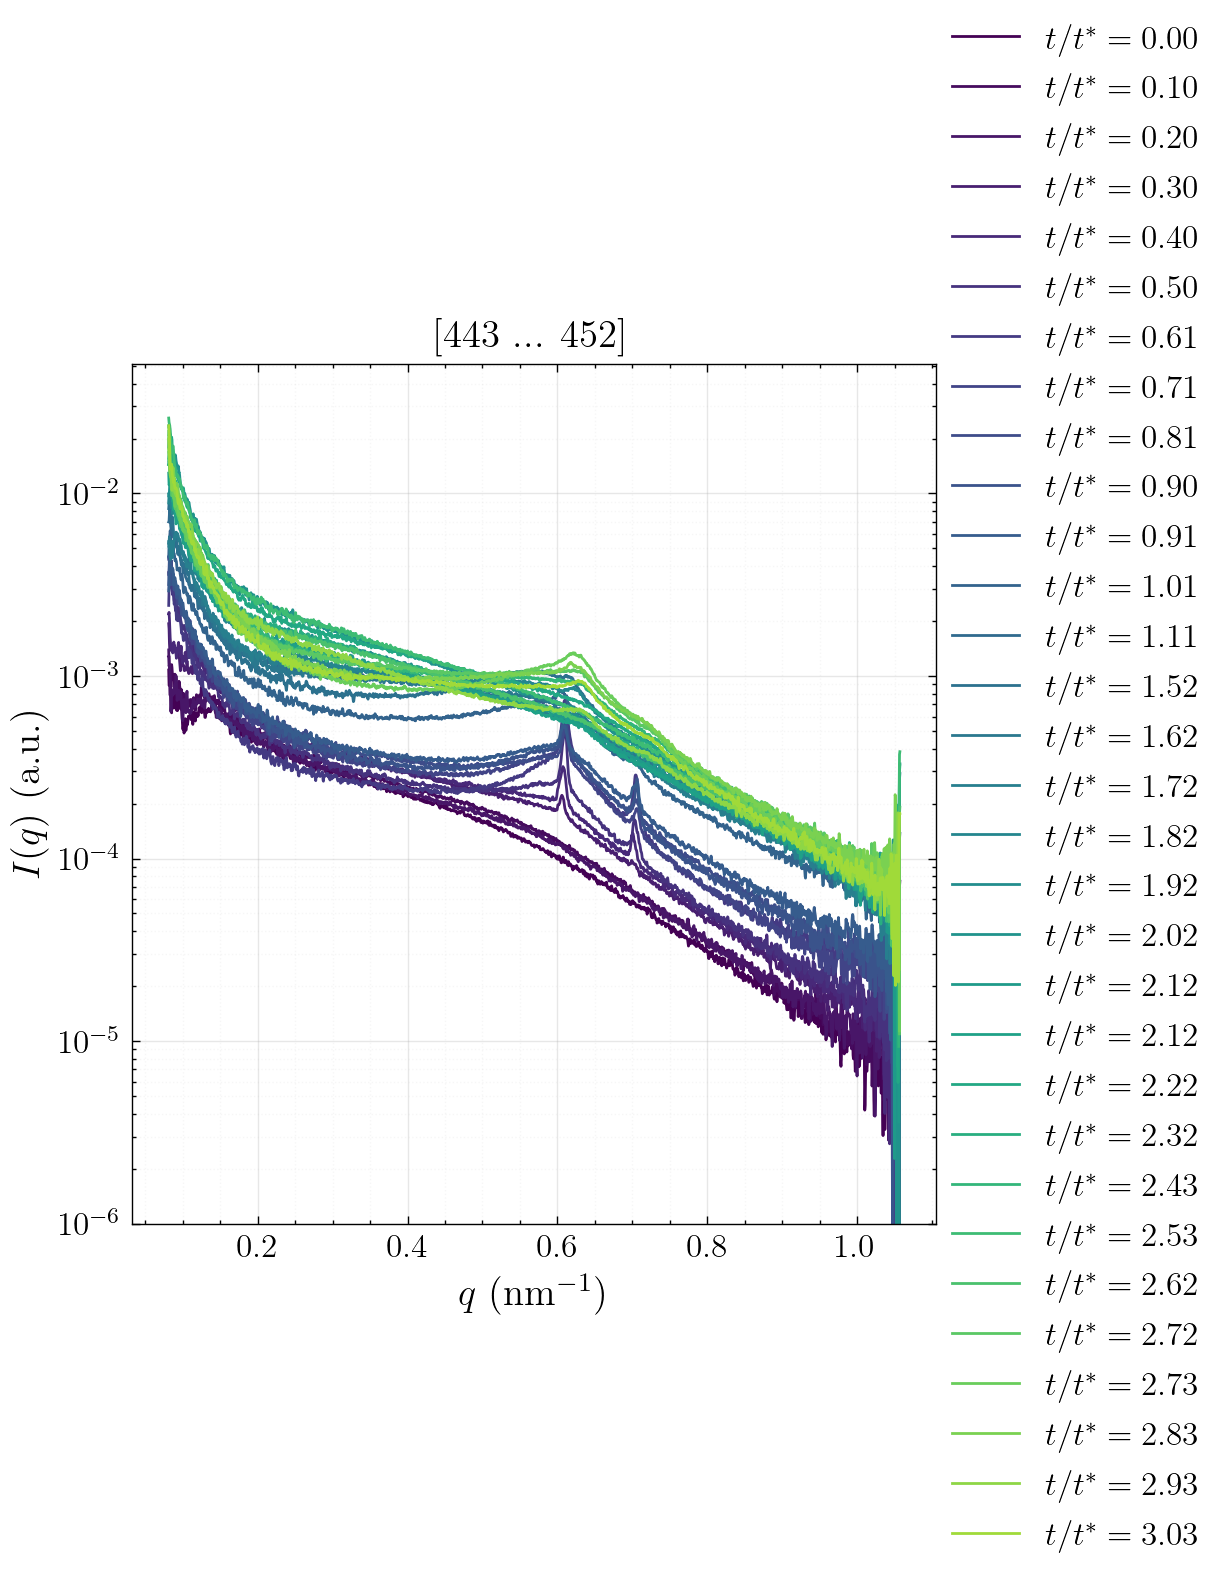

In [82]:
from scipy.signal import find_peaks

run_range = clean_range(list(range(443, 453)))
v = read_volume_series(run_range, db)
timedelta = (v.time - v.isel(trainId=0).time).astype(float)*1e-9
popt, pcov = fit_D2_law(timedelta, v/v[0], t_star_guess=timedelta[len(timedelta)//2])
t_star = popt[-1]
saxs = read_intensity(run_nr, db, variable="agipd_saxs")[:-1]
colors = plt.cm.viridis(np.linspace(0, 1, len(run_range)*len(range(0, len(saxs.trainId), len(saxs.trainId)//3))))

peaks_q = []
peaks_intensity = []

t0 = get_train_timestamps(run_range[0], db)[0]

fig, ax = plt.subplots(figsize=(6, 5))
counter = 0
for idx, run_nr in enumerate(run_range):
    saxs = read_intensity(run_nr, db, variable="agipd_saxs")[:-1]
    ts = get_train_timestamps(run_nr, db)
    timedelta = ((ts - t0).astype(float)*1e-9)
    sc_s = droplet_scaling(run_nr, db, v0_run=run_range[0])
    for tr_idx in range(0, len(saxs.trainId), len(saxs.trainId)//3):
        avg = saxs.isel(trainId=tr_idx).mean("pulseId")
        q, iq = avg.q.values, avg.data
        iq *= sc_s.scale.sel(trainId=avg.trainId).values
        iq_bg_sub = iq - (1 - sc_s.phi_ferritin.isel(trainId=tr_idx).values) * iq_bg
        q = q[iq_bg_sub>0]
        iq_bg_sub = iq_bg_sub[iq_bg_sub>0]
        base = Baseline(q)
        bkg, params = base.arpls(iq_bg_sub, lam=1e6)
        plt.semilogy(q, iq_bg_sub, color=colors[counter], label=f"$t/t^*={timedelta[tr_idx]/t_star:.2f}$")
        # iq_flat = iq_bg_sub-bkg
        # ferritin_peak_range = (q>0.4)&(q<0.8)
        # peaks, _ = find_peaks(iq_flat[ferritin_peak_range], prominence=0.002)
        # peaks_q.append(q[ferritin_peak_range][peaks])
        # peaks_intensity.append(iq_flat[ferritin_peak_range][peaks])
        # plt.plot(q, iq_bg_sub-bkg, color=colors[idx])
        counter += 1
    # plt.vlines(q[ferritin_peak_range][peaks], ymin=0, ymax=0.03)
    # plt.loglog(q_bg_saxs, (1 - sc_s.phi_ferritin.isel(trainId=tr_idx).values) * iq_bg, 'k')
plt.ylim(1e-6,)
# plt.xlim(0.4, 0.8)
# plt.ylim(-0.001, 0.025)
ax.set_title(f"[{run_range[0]} ... {run_range[-1]}]", fontsize=14)
fig.tight_layout()
style_plot(ax, fig_legend=True)
plt.savefig(f"r{run_range[0]}-{run_range[-1]}_saxs_all.png", dpi=300, bbox_inches="tight")
plt.show()